In [1]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from numpy import sin, cos, power, sqrt, pi as π, exp
from sklearn.metrics import mean_absolute_error as mse, r2_score as r2

# Analytical model

## Noise(less) model

In [2]:
def correlation_probability(θ:np.float64,ϕ:np.float64):
    return ( power(sin(ϕ),4) + power(cos(ϕ),4) + 2 * power(sin(ϕ),2) * power(cos(ϕ),2) * ( cos(θ) ))
def model_analytical(θ:np.float64,β:np.float64,α:np.float64):
    return (1./2.)*(correlation_probability(θ,α) + correlation_probability(θ,α + β))
def model_noise_analytical(θ:np.float64,β:np.float64,α:np.float64,Pₜ:np.float64):
    return (1./2.) + Pₜ * model_analytical(θ,β,α)

def model_new_noisy(theta: np.float64, beta: np.float64, alpha: np.float64, p_e: np.float64) -> np.float64:
    sin_a, cos_a = np.sin(alpha), np.cos(alpha)
    sin_ab, cos_ab = np.sin(alpha + beta), np.cos(alpha + beta)
    
    # Calculate the terms for the pure state
    term_alpha = sin_a**4 + cos_a**4
    term_beta = sin_ab**4 + cos_ab**4
    cross_term = 2 * np.cos(theta) * ((sin_a**2 * cos_a**2) + (sin_ab**2 * cos_ab**2))
    
    # The probability of matching results if the state was 100% pure
    pure_prob = 0.5 * (term_alpha + term_beta + cross_term)
    
    # Scale by (1 - P_e) and add the 50% chance from the noise
    return (1.0 - p_e) * pure_prob + (p_e / 2.0)

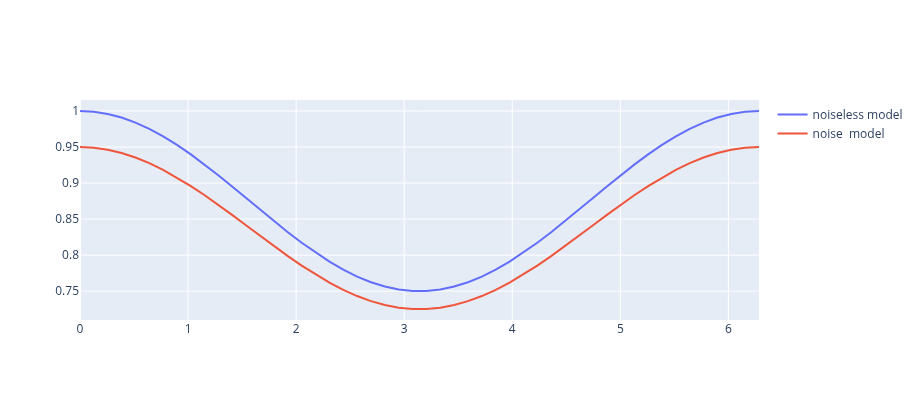

In [10]:
N_samples = 50
Pₑ = 0.1
Pₜ = 1-Pₑ
α = π/8.
β = 3.*π/8.
θ = np.linspace(0,2*π,N_samples)
fig = go.Figure()
fig.add_trace(go.Scatter(
    x = θ, y = model_analytical(θ,β,α),
    name = f"noiseless model",
    mode='lines',
    line=dict(width=2)
))
fig.add_trace(go.Scatter(
    x = θ, y = model_new_noisy(θ,β,α,Pₑ),
    name = f"noise  model",
    mode='lines',
    line=dict(width=2)
))
fig.update_layout(

    width = 700,
    height = 400
)


fig.show()